<a href="https://colab.research.google.com/github/mukul-mschauhan/deep-learning/blob/main/Fashion_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build a simple and easy-to-follow Neural Network model using Keras for multi-class classification on the Fashion MNIST dataset. Include comments to explain the code, the neural network architecture (layers, activation functions), and the rationale behind the choices.

## Load and explore the dataset

### Subtask:
Load the Fashion MNIST dataset and explore its structure and characteristics.


**Reasoning**:
Load the Fashion MNIST dataset and explore its structure and characteristics by printing shapes, data types, pixel value ranges, and sample labels as per the instructions.



In [2]:
!pip install -q keras tensorflow

In [18]:
from tensorflow.keras.datasets import fashion_mnist

# Load the training and testing data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Print the shapes of the datasets
print("Shape of x_train:", x_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_test:", y_test.shape)

# Print the data type of x_train
print("Data type of x_train:", x_train.dtype)

# Print the minimum and maximum pixel values in x_train
print("Minimum pixel value in x_train:", x_train.min())
print("Maximum pixel value in x_train:", x_train.max())

# Print the first few labels from y_train
print("First few labels from y_train:", y_train[:10])

Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)
Data type of x_train: uint8
Minimum pixel value in x_train: 0
Maximum pixel value in x_train: 255
First few labels from y_train: [9 0 0 3 0 2 7 2 5 5]


## Lets Visualize the Dataset

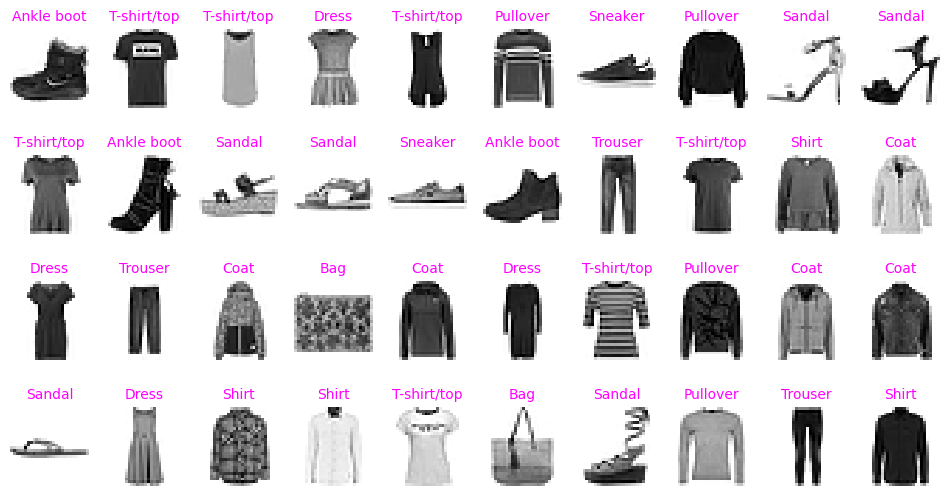

In [25]:
nrows = 4
ncols = 10

plt.figure(figsize = (ncols*1.2, nrows*1.5))

for row in range(nrows):
  for col in range(ncols):
    index = ncols*row+col
    plt.subplot(nrows, ncols, index+1)
    plt.imshow(x_train[index].reshape(28,28), cmap = 'binary', interpolation = 'nearest')
    plt.axis('off')
    plt.title(class_names[y_train[index]], fontsize = 10, color = "magenta") # Changed fontcolor to color

plt.subplots_adjust(wspace = 0.2, hspace = 0.5)
plt.show()

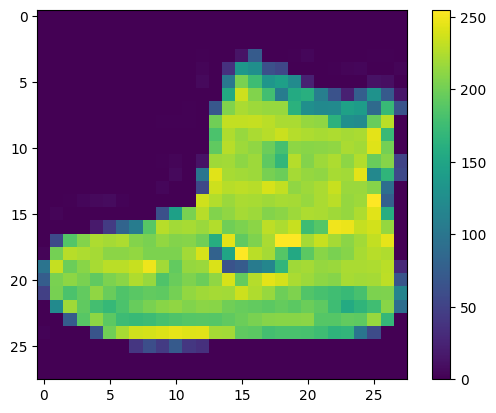

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
plt.imshow(x_train[0].reshape(28, 28)) # Reshape to 28x28 for plotting
plt.colorbar()
plt.grid(False)
plt.show()

Each image (instance) in the dataset has 784 pixels (features) and value of each feature(pixel) ranges from 0 to 255, this range is too wide, hence we have performed feature scaling (using Standardization) on the training dataset, so that values of all features (pixels) are in a small range.

## Preprocess the data

### Subtask:
Prepare the data for the neural network by normalizing the pixel values and reshaping the images.

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the training set and the testing set be preprocessed in the same way:


**Reasoning**:
Normalize the pixel values and reshape the images for the neural network.



In [3]:
# Normalize the pixel values
x_train = x_train / 255.0
x_test = x_test / 255.0

# Reshape the images
x_train = x_train.reshape(x_train.shape[0], 28 * 28)
x_test = x_test.reshape(x_test.shape[0], 28 * 28)

# Print the shapes of the preprocessed data
print("Shape of preprocessed x_train:", x_train.shape)
print("Shape of preprocessed x_test:", x_test.shape)

Shape of preprocessed x_train: (60000, 784)
Shape of preprocessed x_test: (10000, 784)


## Build the neural network model

### Subtask:
Design and build a simple neural network model using Keras, explaining the layers and activation functions used.


**Reasoning**:
Import necessary modules and build the neural network model with specified layers and activation functions.



In [4]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model
model = Sequential()

# Add the first Dense layer (input layer and first hidden layer)
# This layer has 128 neurons. The input shape is 784 (28*28) after flattening the images.
# The 'relu' activation function introduces non-linearity, allowing the model to learn more complex patterns.
model.add(Dense(128, activation='relu', input_shape=(784,)))

# Add a second Dense layer (hidden layer)
# This layer has 64 neurons and uses the 'relu' activation function for non-linearity.
model.add(Dense(64, activation='relu'))

# Add the output Dense layer
# This layer has 10 neurons, one for each class in the Fashion MNIST dataset.
# The 'softmax' activation function outputs a probability distribution over the classes,
# making it suitable for multi-class classification.
model.add(Dense(10, activation='softmax'))

# Print a summary of the model
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the model

### Subtask:
Configure the model for training by specifying the optimizer, loss function, and metrics.


**Reasoning**:
Configure the Keras model for training by compiling it with the specified optimizer, loss function, and metrics.



In [5]:
# Configure the model for training
# Use the 'adam' optimizer, which is a popular and effective optimization algorithm.
# Use 'sparse_categorical_crossentropy' as the loss function, suitable for multi-class classification
# with integer labels (like the Fashion MNIST labels).
# Monitor 'accuracy' during training to evaluate the model's performance.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# The model is now configured for training.
print("Model compilation complete.")

Model compilation complete.


## Train the model

### Subtask:
Train the neural network model on the preprocessed data.


**Reasoning**:
Train the compiled Keras model using the preprocessed training data and labels, specifying the number of epochs and including validation data.



In [7]:
# Train the model
# Use the .fit() method to train the model on the training data.
# x_train: Preprocessed training images
# y_train: Training labels
# epochs: Number of training iterations over the entire dataset. 10 epochs are used here.
# validation_data: Provide test data (x_test, y_test) to monitor performance on unseen data during training.
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9142 - loss: 0.2276 - val_accuracy: 0.8810 - val_loss: 0.3388
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9166 - loss: 0.2160 - val_accuracy: 0.8846 - val_loss: 0.3486
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9214 - loss: 0.2070 - val_accuracy: 0.8874 - val_loss: 0.3313
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9242 - loss: 0.1999 - val_accuracy: 0.8830 - val_loss: 0.3657
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9262 - loss: 0.1956 - val_accuracy: 0.8882 - val_loss: 0.3423
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9268 - loss: 0.1920 - val_accuracy: 0.8849 - val_loss: 0.3571
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9306 - loss: 0.1833 - val_accuracy: 0.8710 - val_loss: 0.4016
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9303 - loss: 0.1812 

## Evaluate the Model

### Subtask:
Evaluate the performance of the trained model on the test set.

**Reasoning**:
Evaluate the trained Keras model on the preprocessed test data and labels to assess its performance on unseen data.

In [8]:
# Evaluate the model
# Use the .evaluate() method to evaluate the model on the test data.
# x_test: Preprocessed test images
# y_test: Test labels
# verbose=0: Suppress progress bar during evaluation for cleaner output.
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

# Print the evaluation results
print(f'Test loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

Test loss: 0.3609
Test accuracy: 0.8906


## Visualize Predictions

### Subtask:
Visualize some predictions to understand how the model is performing.

**Reasoning**:
Make predictions on the test set and visualize a few images along with their true and predicted labels to understand the model's performance.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


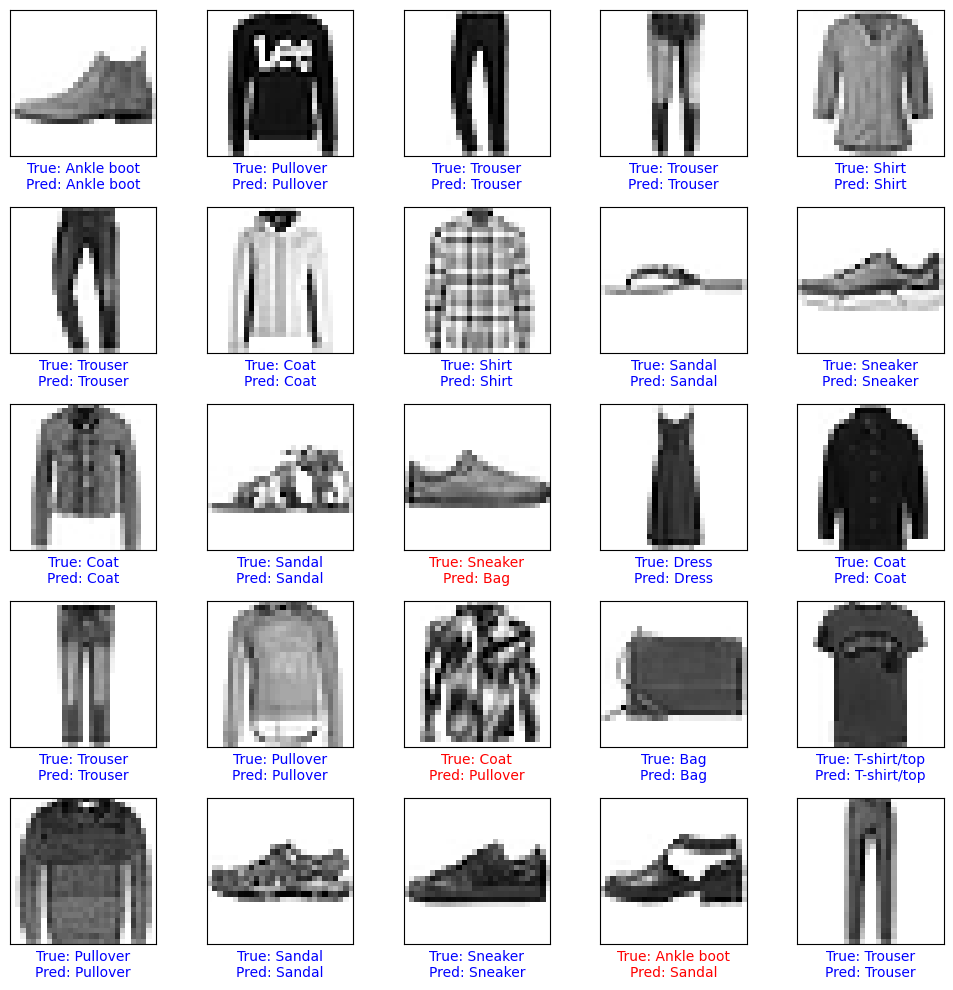

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Get the model's predictions for the test set
predictions = model.predict(x_test)

# Get the predicted labels
predicted_labels = np.argmax(predictions, axis=1)

# Define class names for Fashion MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Visualize some predictions
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Reshape the image back to 28x28 for visualization
    plt.imshow(x_test[i].reshape(28, 28), cmap=plt.cm.binary)
    true_label = class_names[y_test[i]]
    predicted_label = class_names[predicted_labels[i]]
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"True: {true_label}\nPred: {predicted_label}", color=color)
plt.tight_layout()
plt.show()

## Summary

We successfully built and evaluated a simple neural network model using Keras for multi-class classification on the Fashion MNIST dataset.

**Process:**

1.  **Data Loading and Exploration:** We loaded the Fashion MNIST dataset, which consists of 60,000 training images and 10,000 test images of fashion items, each with a resolution of 28x28 pixels. We examined the shapes, data types, and pixel value range of the dataset.
2.  **Data Preprocessing:** We preprocessed the data by normalizing the pixel values to the range [0, 1] and reshaping the 28x28 images into a flat vector of 784 features.
3.  **Model Building:** We designed a simple Sequential neural network model with three Dense layers:
    *   An input layer with 128 neurons and 'relu' activation.
    *   A hidden layer with 64 neurons and 'relu' activation.
    *   An output layer with 10 neurons (one for each class) and 'softmax' activation for multi-class probability distribution.
4.  **Model Compilation:** We compiled the model using the 'adam' optimizer, 'sparse_categorical_crossentropy' loss function (suitable for integer labels), and 'accuracy' as the evaluation metric.
5.  **Model Training:** We trained the model on the preprocessed training data for 10 epochs, using the test data for validation to monitor performance on unseen data.
6.  **Model Evaluation:** We evaluated the trained model on the test set, which showed a test accuracy of approximately 89.06%.
7.  **Prediction Visualization:** We visualized some predictions on the test set, displaying images with their true and predicted labels to get a visual understanding of the model's performance and identify potential misclassifications.

**Results:**

The model achieved a test accuracy of approximately 89.06% on the Fashion MNIST dataset, demonstrating its ability to classify the different fashion items with reasonable accuracy. The visualization of predictions provided insights into where the model performed well and where it made errors.

This simple neural network provides a good starting point for understanding and applying deep learning to image classification tasks.